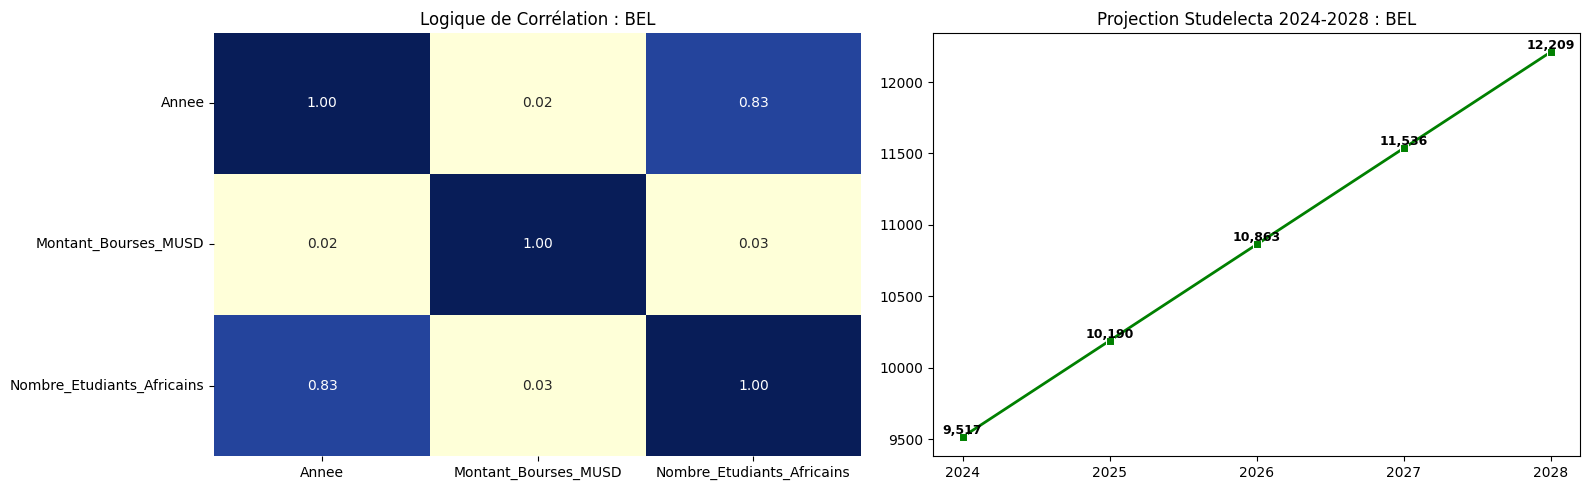

✅ ANALYSE DE FIABILITÉ POUR BEL :
   -> Pourcentage de confiance (R²) : 68.99%
   -> Marge d'erreur moyenne : ± 904 étudiants
------------------------------------------------------------


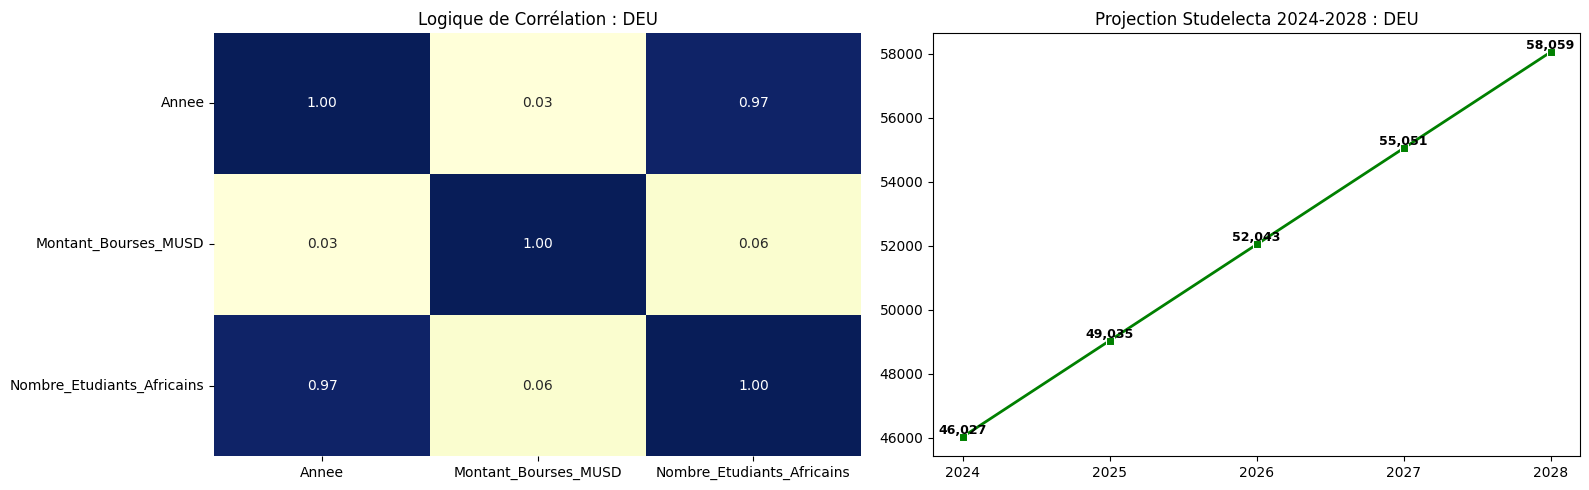

✅ ANALYSE DE FIABILITÉ POUR DEU :
   -> Pourcentage de confiance (R²) : 93.47%
   -> Marge d'erreur moyenne : ± 1651 étudiants
------------------------------------------------------------


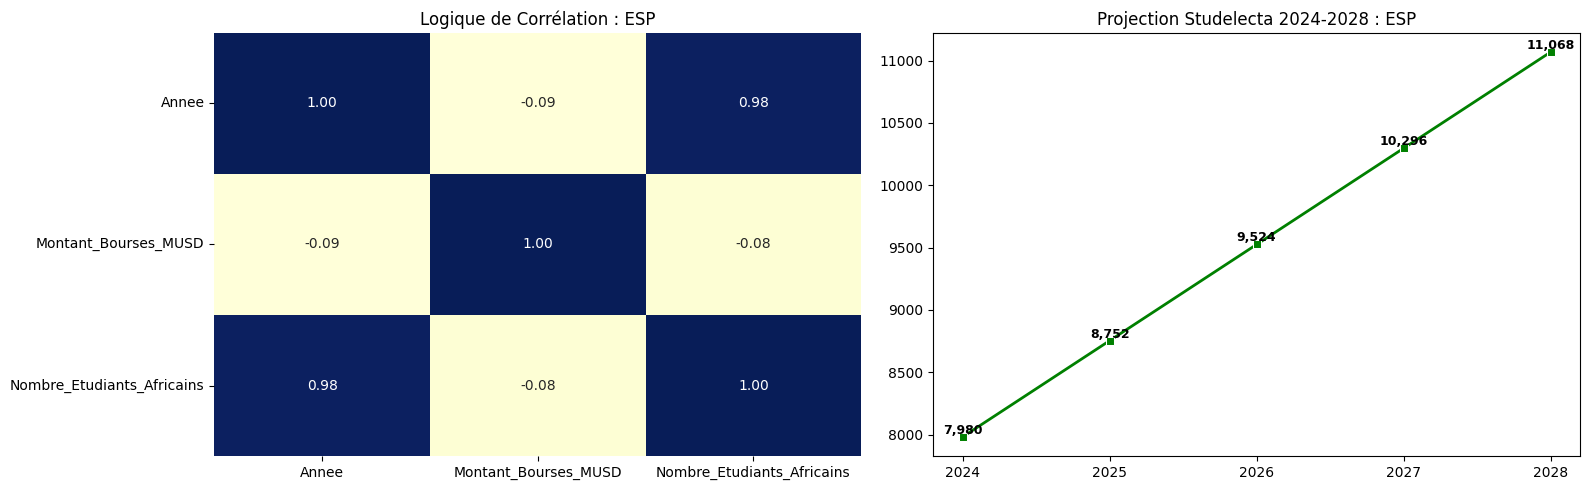

✅ ANALYSE DE FIABILITÉ POUR ESP :
   -> Pourcentage de confiance (R²) : 95.80%
   -> Marge d'erreur moyenne : ± 322 étudiants
------------------------------------------------------------


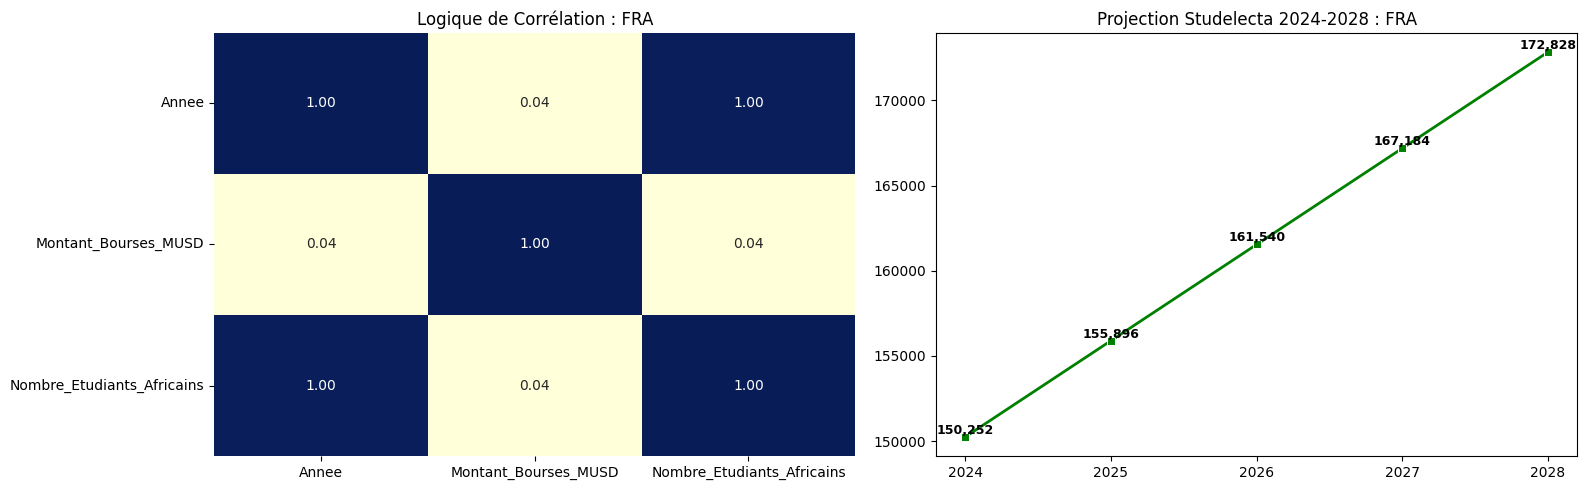

✅ ANALYSE DE FIABILITÉ POUR FRA :
   -> Pourcentage de confiance (R²) : 99.16%
   -> Marge d'erreur moyenne : ± 1068 étudiants
------------------------------------------------------------


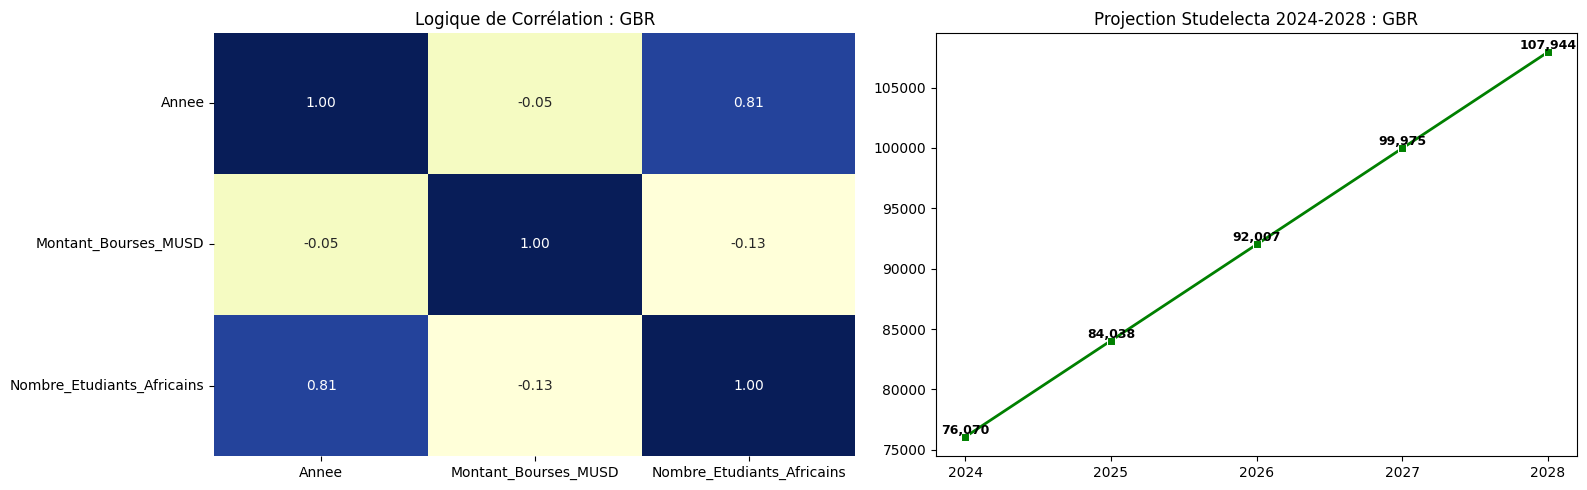

✅ ANALYSE DE FIABILITÉ POUR GBR :
   -> Pourcentage de confiance (R²) : 65.07%
   -> Marge d'erreur moyenne : ± 10939 étudiants
------------------------------------------------------------


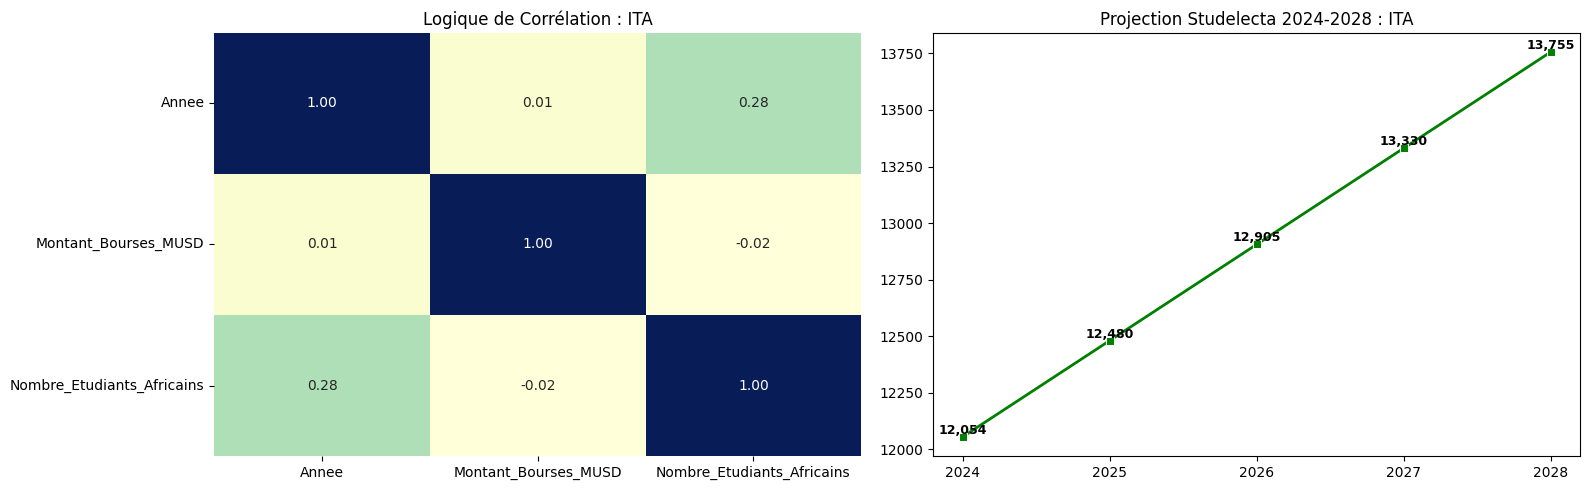

✅ ANALYSE DE FIABILITÉ POUR ITA :
   -> Pourcentage de confiance (R²) : 7.86%
   -> Marge d'erreur moyenne : ± 2815 étudiants
------------------------------------------------------------


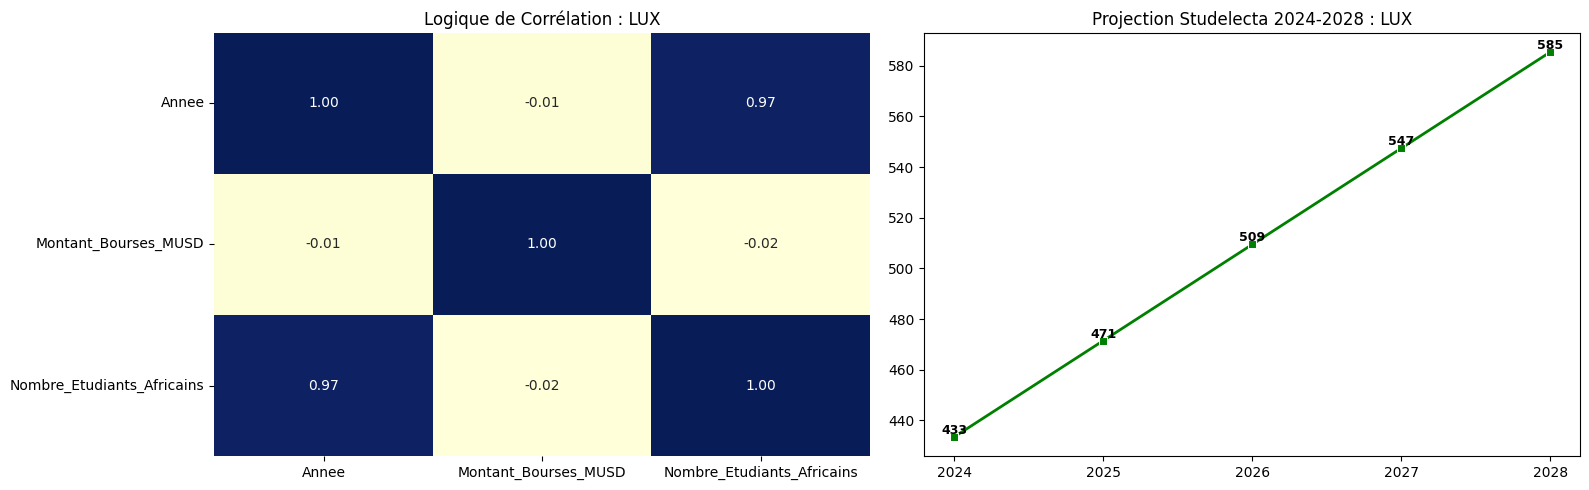

✅ ANALYSE DE FIABILITÉ POUR LUX :
   -> Pourcentage de confiance (R²) : 94.50%
   -> Marge d'erreur moyenne : ± 17 étudiants
------------------------------------------------------------

CLASSEMENTS ANNUELS AVEC PROGRESSION (2024-2028)

--- TOP DESTINATIONS 2024 ---
  Pays  Étudiants
1  FRA     150252
2  GBR      76070
3  DEU      46027
4  ITA      12054
5  BEL       9517
6  ESP       7980
7  LUX        433

--- TOP DESTINATIONS 2025 ---
  Pays  Étudiants
1  FRA     155896
2  GBR      84038
3  DEU      49035
4  ITA      12480
5  BEL      10190
6  ESP       8752
7  LUX        471

--- TOP DESTINATIONS 2026 ---
  Pays  Étudiants
1  FRA     161540
2  GBR      92007
3  DEU      52043
4  ITA      12905
5  BEL      10863
6  ESP       9524
7  LUX        509

--- TOP DESTINATIONS 2027 ---
  Pays  Étudiants
1  FRA     167184
2  GBR      99975
3  DEU      55051
4  ITA      13330
5  BEL      11536
6  ESP      10296
7  LUX        547

--- TOP DESTINATIONS 2028 ---
  Pays  Étudiants
1  FRA     1728

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Chargement
df = pd.read_csv('/content/Dataset_Studelecta_Final_2026 (2).csv')

# 2. Paramètres
pays_europeens = ['BEL', 'DEU', 'ESP', 'FRA', 'GBR', 'ITA', 'LUX']
annees_futures = [2024, 2025, 2026, 2027, 2028]
resultats_liste = []

# 3. Boucle par pays : Analyse + Prédiction + Évaluation
for code in pays_europeens:
    data_pays = df[df['Code_Destination'] == code].copy()

    # --- ENTRAÎNEMENT DU MODÈLE ---
    model = LinearRegression()
    model.fit(data_pays[['Annee']], data_pays['Nombre_Etudiants_Africains'])

    # --- CALCUL DE LA FIABILITÉ (Évaluation) ---
    # On prédit sur les données passées pour comparer avec le réel
    y_reel = data_pays['Nombre_Etudiants_Africains']
    y_pred_passe = model.predict(data_pays[['Annee']])

    fiabilite = r2_score(y_reel, y_pred_passe) # Le score R²
    erreur_moyenne = mean_absolute_error(y_reel, y_pred_passe) # La marge d'erreur

    # --- PRÉDICTION FUTURE ---
    futur_X = pd.DataFrame({'Annee': annees_futures})
    preds_futures = model.predict(futur_X)

    # Stockage
    for annee, val in zip(annees_futures, preds_futures):
        resultats_liste.append({
            'Année': annee,
            'Pays': code,
            'Étudiants': int(val)
        })

    # --- AFFICHAGE GRAPHIQUE ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Gauche : Corrélation
    sns.heatmap(data_pays[['Annee', 'Montant_Bourses_MUSD', 'Nombre_Etudiants_Africains']].corr(),
                annot=True, cmap='YlGnBu', fmt=".2f", ax=ax1, cbar=False)
    ax1.set_title(f'Logique de Corrélation : {code}')

    # Droite : Projection
    sns.lineplot(x=annees_futures, y=preds_futures, marker='s', ax=ax2, color='green', linewidth=2)
    for x, y in zip(annees_futures, preds_futures):
        ax2.text(x, y, f'{int(y):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2.set_title(f'Projection Studelecta 2024-2028 : {code}')
    ax2.set_xticks(annees_futures)

    plt.tight_layout()
    plt.show()

    # --- AFFICHAGE DES SCORES DE FIABILITÉ ---
    print(f"✅ ANALYSE DE FIABILITÉ POUR {code} :")
    print(f"   -> Pourcentage de confiance (R²) : {fiabilite:.2%}")
    print(f"   -> Marge d'erreur moyenne : ± {int(erreur_moyenne)} étudiants")
    print("-" * 60)

# 4. CLASSEMENTS ANNUELS
df_final = pd.DataFrame(resultats_liste)
print("\n" + "="*60)
print("CLASSEMENTS ANNUELS AVEC PROGRESSION (2024-2028)")
print("="*60)

for annee in annees_futures:
    print(f"\n--- TOP DESTINATIONS {annee} ---")
    top = df_final[df_final['Année'] == annee].sort_values(by='Étudiants', ascending=False)
    top = top.reset_index(drop=True)
    top.index += 1
    print(top[['Pays', 'Étudiants']])